#### Helpers

In [1]:
import addcopyfighandler
%matplotlib widget
import matplotlib.pyplot as plt

def plot_bid_ask_mid(show_df, title):
  plt.figure(figsize=(11, 7))

  plt.scatter(show_df.index, show_df['bid_price_1'], color='seagreen', label='Bid', s=2, alpha=0.6)
  plt.scatter(show_df.index, show_df['ask_price_1'], color='crimson', label='Ask', s=2, alpha=0.6)

  plt.scatter(show_df.index, show_df['bid_price_2'], color='seagreen', label='Ask', s=2, alpha=0.3)
  plt.scatter(show_df.index, show_df['ask_price_2'], color='crimson', label='Ask', s=2, alpha=0.3)

  plt.scatter(show_df.index, show_df['bid_price_3'], color='black', label='Ask', s=2, alpha=0.6)
  plt.scatter(show_df.index, show_df['ask_price_3'], color='black', label='Ask', s=2, alpha=0.6)

  plt.plot(show_df.index, show_df['mid_price'], color='royalblue', label='Mid Price', linewidth=1, alpha=0.8)

  # Formatting
  plt.title(title, fontsize=14)
  plt.xlabel('Index / Time')
  plt.ylabel('Price')
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.legend(markerscale=5) # Makes legend dots bigger so you can see the colors

  plt.tight_layout()
  plt.show()

def plot_trades_on_bid_ask_mid(trades_set, outer_set, window = 3, title = 'Trades over Bid/Mid/Ask Prices'):
  show_df = set()

  for idx in trades_set.index:
    # Find the numeric position (row number) of the match
    try:
      pos = outer_set.index.get_loc(idx)
        
      # Define the window (clamped to ensure we don't go out of bounds)
      start = max(0, pos - window)
      end = min(len(outer_set), pos + window + 1)
        
      # Add these specific index values to our set
      show_df.update(outer_set.index[start:end])
    except KeyError:
      continue # Skip if index isn't in the big DF
  
  show_df = outer_set.loc[sorted(list(show_df))]
  show_df = show_df.join(trades_set[['price', 'quantity']], how='left') # Join the trades data to the show_df for plotting

  fig, ax = plt.subplots(figsize=(11, 7))

  ax.scatter(show_df.index, show_df['bid_price_1'], color='seagreen', label='Bid Price 1', s=33, alpha=0.6)
  ax.scatter(show_df.index, show_df['ask_price_1'], color='crimson', label='Ask Price 1', s=33, alpha=0.6)
  ax.scatter(show_df.index, show_df['bid_price_2'], color='yellow', label='Bid Price 2', s=33, alpha=0.3)
  ax.scatter(show_df.index, show_df['ask_price_2'], color='yellow', label='Ask Price 2', s=33, alpha=0.3)
  ax.scatter(show_df.index, show_df['bid_price_3'], color='black', label='Bid Price 3', s=33, alpha=0.3)
  ax.scatter(show_df.index, show_df['ask_price_3'], color='black', label='Ask Price 3', s=33, alpha=0.3)
  ax.plot(show_df.index, show_df['mid_price'], color='royalblue', label='Mid Price', linewidth=1, alpha=0.6)

  stars = ax.scatter(show_df.index, show_df['price'], marker='*', color='black', s=200, label='Trade Entry', zorder=5, facecolor='none', linewidth=1.5, picker=5)

  annot = ax.annotate("", xy=(0,0), xytext=(10,10),
                    textcoords="offset points",
                    bbox=dict(boxstyle="round", fc="white", alpha=0.9),
                    arrowprops=dict(arrowstyle="->"))
  annot.set_visible(False)

  # The Click Handler
  def on_pick(event):
      if event.artist == stars:
          # Get index of the clicked star
          idx = event.ind[0]
          
          # Get coordinates and data
          pos = stars.get_offsets()[idx]
          qty = show_df.iloc[idx]['quantity']
          
          # Move and show the label
          annot.xy = pos
          annot.set_text(f"Qty: {qty}")
          annot.set_visible(True)
          
          fig.canvas.draw_idle()

  # Connect the event
  fig.canvas.mpl_connect("pick_event", on_pick)
  plt.xlabel('Timestamp')
  plt.ylabel('Price')
  plt.title(title)
  plt.legend()
  plt.show()

### Visualization

In [2]:
import pandas as pd
import seaborn as sns

# Load the dataset
df = pd.read_csv("round5/prices_round_5_day_2.csv", sep=";")
df2 = pd.read_csv("round5/prices_round_5_day_3.csv", sep=";")
df3 = pd.read_csv("round5/prices_round_5_day_4.csv", sep=";")


trades = pd.read_csv("round5/trades_round_5_day_2.csv", sep=";")
trades2 = pd.read_csv("round5/trades_round_5_day_3.csv", sep=";")
trades3 = pd.read_csv("round5/trades_round_5_day_4.csv", sep=";")


# Display the first few rows of the dataset
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   day              500000 non-null  int64  
 1   timestamp        500000 non-null  int64  
 2   product          500000 non-null  str    
 3   bid_price_1      500000 non-null  int64  
 4   bid_volume_1     500000 non-null  int64  
 5   bid_price_2      479890 non-null  float64
 6   bid_volume_2     479890 non-null  float64
 7   bid_price_3      8108 non-null    float64
 8   bid_volume_3     8108 non-null    float64
 9   ask_price_1      500000 non-null  int64  
 10  ask_volume_1     500000 non-null  int64  
 11  ask_price_2      480029 non-null  float64
 12  ask_volume_2     480029 non-null  float64
 13  ask_price_3      8045 non-null    float64
 14  ask_volume_3     8045 non-null    float64
 15  mid_price        500000 non-null  float64
 16  profit_and_loss  500000 non-null  float64
dtypes:

### VELVETFRUIT_EXTRACT

In [3]:
# GET PRODUCT DATA

PRODUCT_NAME = 'SNACKPACK_RASPBERRY'

product_df = df[df['product'] == PRODUCT_NAME]
product_df_2 = df2[df2['product'] == PRODUCT_NAME]
product_df_3 = df3[df3['product'] == PRODUCT_NAME]

product_trades = trades[trades['symbol'] == PRODUCT_NAME]
product_trades_2 = trades2[trades2['symbol'] == PRODUCT_NAME]
product_trades_3 = trades3[trades3['symbol'] == PRODUCT_NAME]

# product_df.info()

product_df.set_index('timestamp', inplace=True)
product_df_2.set_index('timestamp', inplace=True)
product_df_3.set_index('timestamp', inplace=True)

product_trades.set_index('timestamp', inplace=True)
product_trades_2.set_index('timestamp', inplace=True)
product_trades_3.set_index('timestamp', inplace=True)

# No trading data for product, all mid prices are 0.01 or less
print((product_df['mid_price'] <= 0.01).sum())
print((product_df_2['mid_price'] <= 0.01).sum())
print((product_df_3['mid_price'] <= 0.01).sum())


#drop the rows with mid_price <= 0.01
product_df = product_df[product_df['mid_price'] > 0.01]
product_df_2 = product_df_2[product_df_2['mid_price'] > 0.01]
product_df_3 = product_df_3[product_df_3['mid_price'] > 0.01]

0
0
0


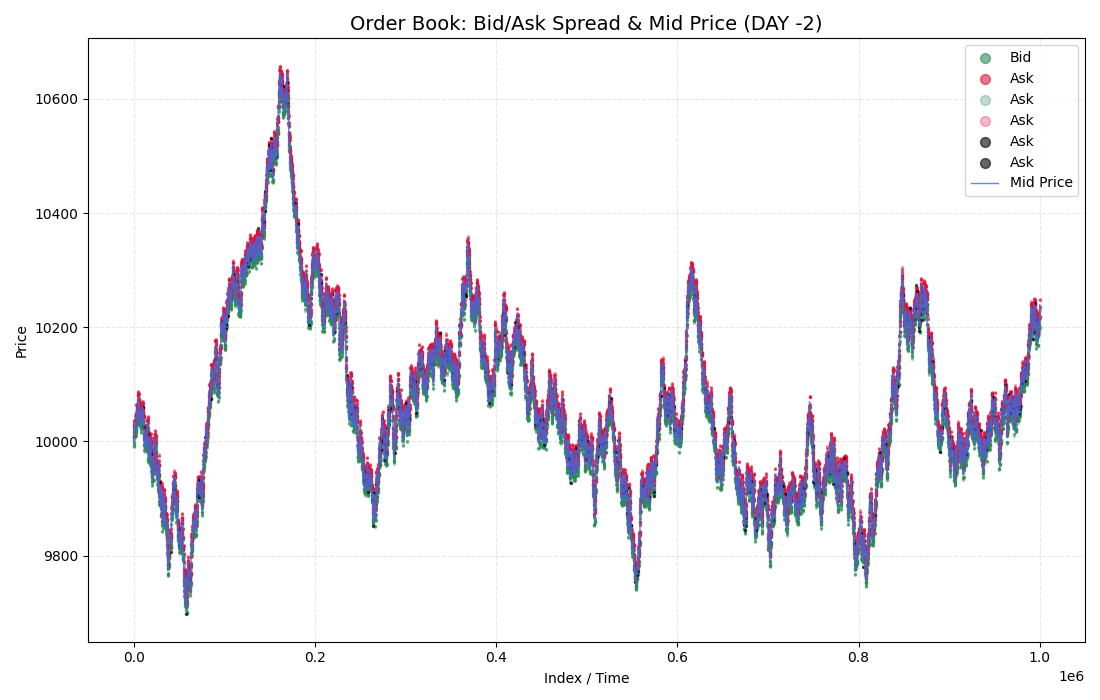

In [4]:
show_df = product_df[:] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY -2)")

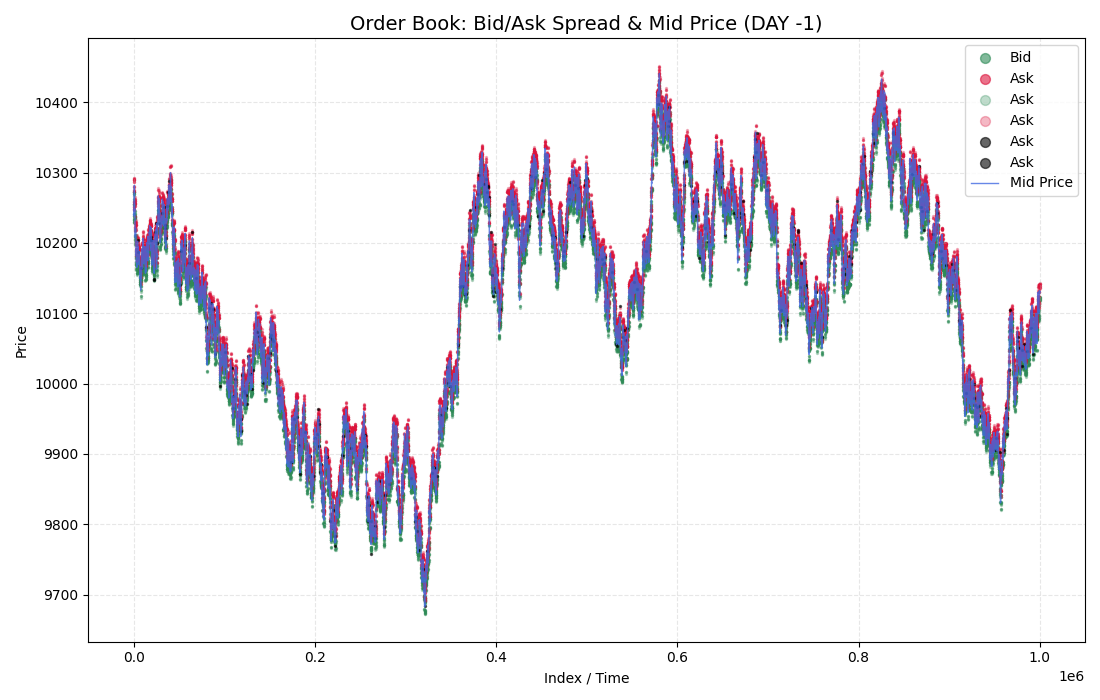

In [5]:
show_df = product_df_2[0:10000] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY -1)")

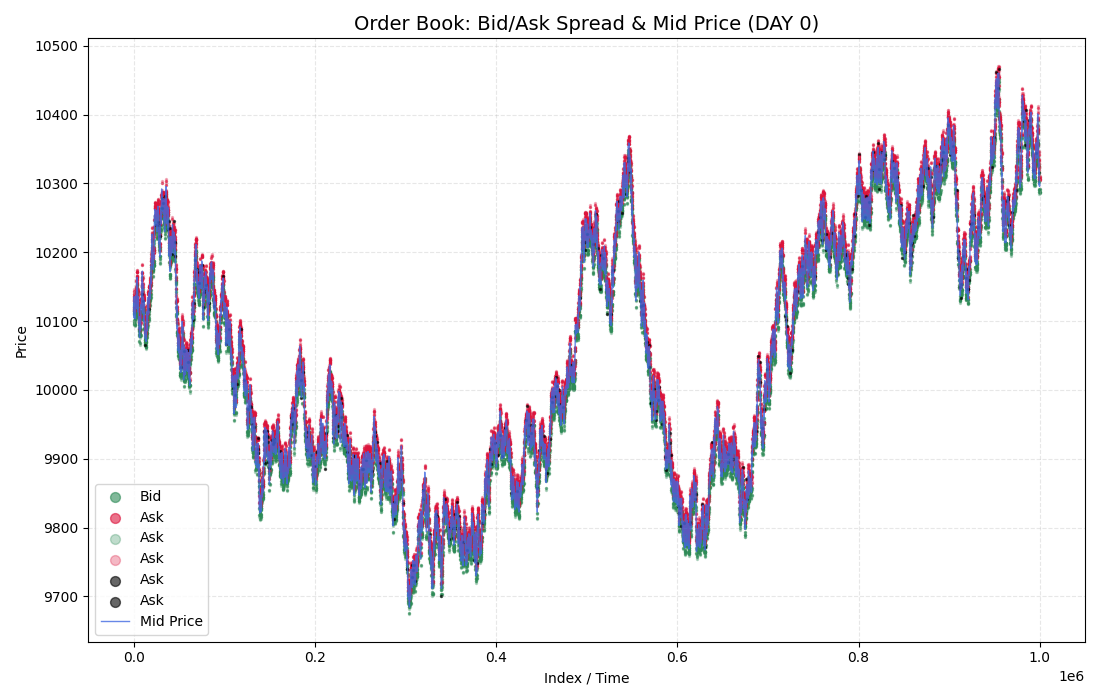

In [6]:
show_df = product_df_3[:] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY 0)")

### Mid-price vs Trades

In [7]:
# match the trades with the order book data and plot the trades on top of the bid/ask spread

midtrade_df = product_df.join(product_trades, how='inner') # Control the days to show trades for by changing the dataframes here
show_df = midtrade_df[:] # Controls how many trades to show on the plot (around 400 trades in total)

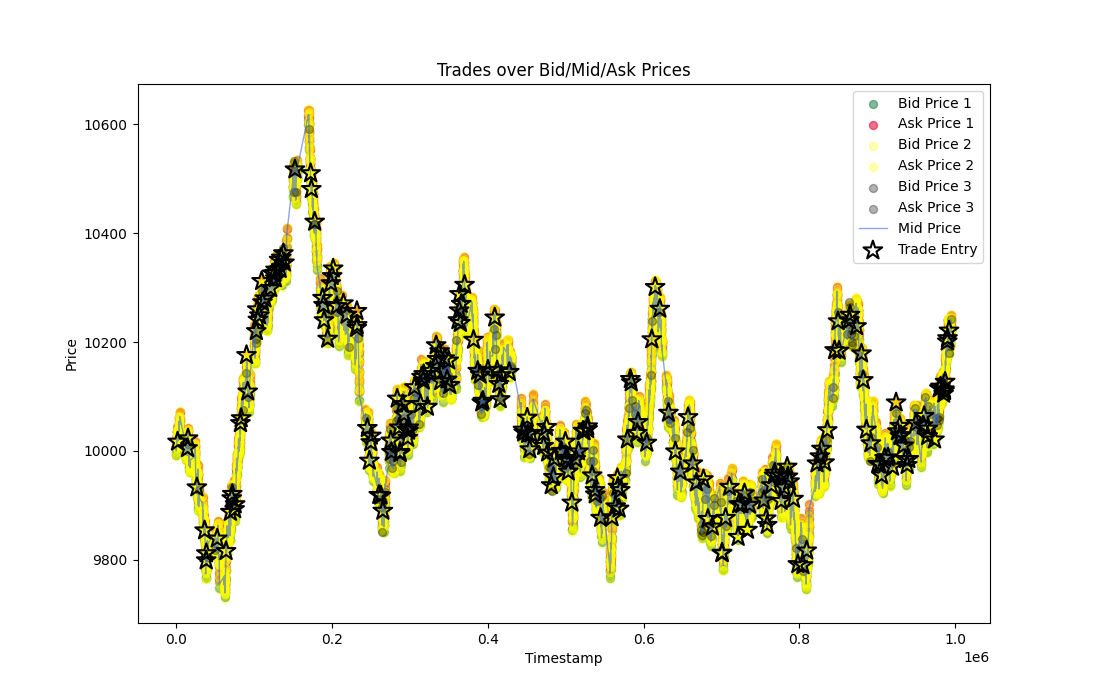

In [8]:
plot_trades_on_bid_ask_mid(show_df, product_df, window=29, title='Trades over Bid/Mid/Ask Prices')

#### Volume Analysis

Trade prices range:
10517.0
9790.0
10070.152838427948

Trade prices range:
10423.0
9723.0
10128.239215686275

Trade prices range:
10434.0
9697.0
10060.349397590362


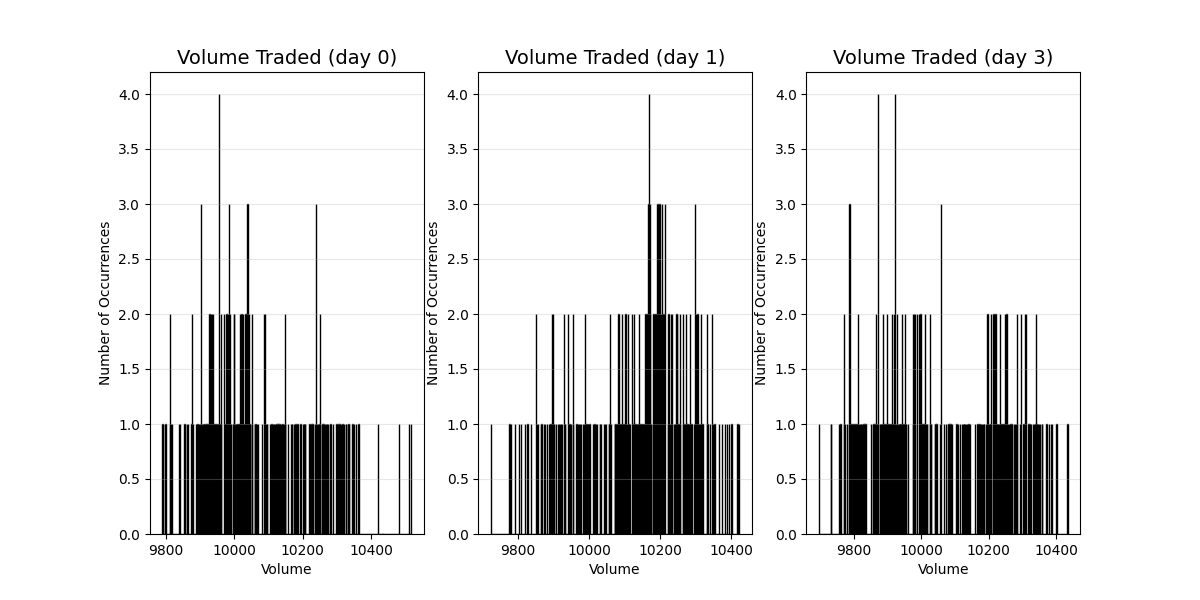

In [9]:
print("Trade prices range:")

print(product_trades['price'].max())
print(product_trades['price'].min())
print(product_trades['price'].mean())


print("\nTrade prices range:")

print(product_trades_2['price'].max())
print(product_trades_2['price'].min())
print(product_trades_2['price'].mean())

print("\nTrade prices range:")

print(product_trades_3['price'].max())
print(product_trades_3['price'].min())
print(product_trades_3['price'].mean())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))

ax1.hist(product_trades['price'].dropna(), bins=1000, color='royalblue', edgecolor='black')

ax1.set_title('Volume Traded (day 0)', fontsize=14)
ax1.set_xlabel('Volume')
ax1.set_ylabel('Number of Occurrences')
ax1.grid(axis='y', alpha=0.3)

ax2.hist(product_trades_2['price'].dropna(), bins=1000, color='royalblue', edgecolor='black')

ax2.set_title('Volume Traded (day 1)', fontsize=14)
ax2.set_xlabel('Volume')
ax2.set_ylabel('Number of Occurrences')
ax2.grid(axis='y', alpha=0.3)

ax3.hist(product_trades_3['price'].dropna(), bins=1000, color='royalblue', edgecolor='black')

ax3.set_title('Volume Traded (day 3)', fontsize=14)
ax3.set_xlabel('Volume')
ax3.set_ylabel('Number of Occurrences')
ax3.grid(axis='y', alpha=0.3)

# Day -2 volume
	 - Total volume traded:  562
	 - Max volume traded:  4
	 - Min volume traded:  1
	 - Average volume traded:  2.4541484716157207
# Day -1 volume
	 - Total volume traded:  649
	 - Max volume traded:  4
	 - Min volume traded:  1
	 - Average volume traded:  2.545098039215686
# Day 0 volume
	 - Total volume traded:  594
	 - Max volume traded:  4
	 - Min volume traded:  1
	 - Average volume traded:  2.3855421686746987


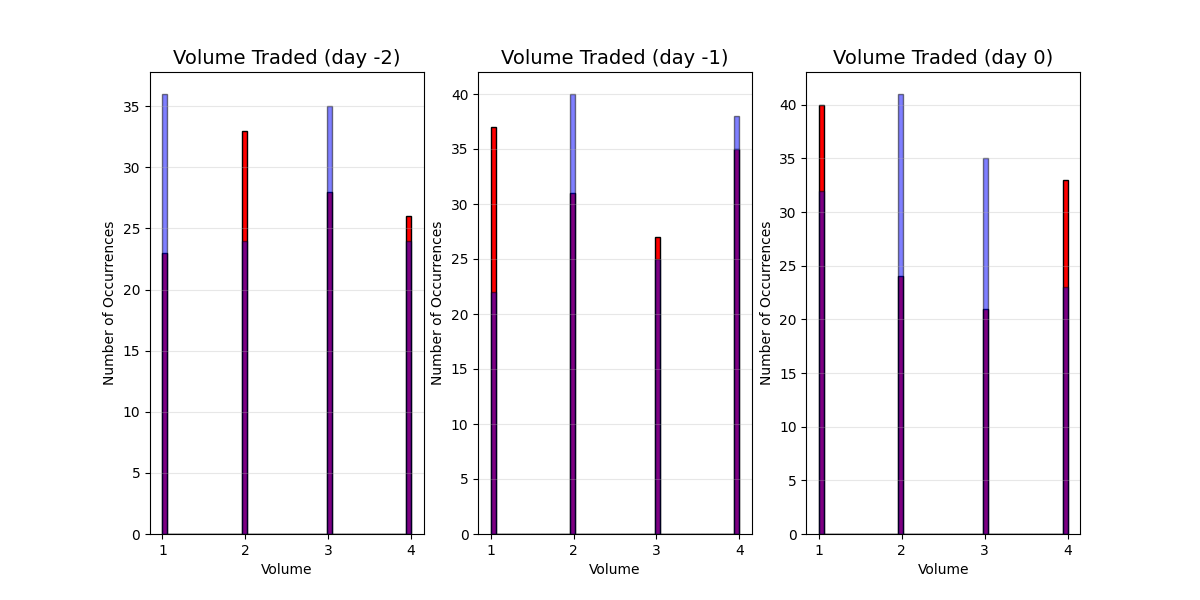

In [10]:
print("# Day -2 volume")
print("\t - Total volume traded: ", product_trades['quantity'].sum())
print("\t - Max volume traded: ", product_trades['quantity'].max())
print("\t - Min volume traded: ", product_trades['quantity'].min())
print("\t - Average volume traded: ", product_trades['quantity'].mean())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))

# Products trades where price == ask_price_0
product_trades_ask = midtrade_df[midtrade_df['price'] == midtrade_df['ask_price_1']]
# Product trades where price == bid_price_0
product_trades_bid = midtrade_df[midtrade_df['price'] == midtrade_df['bid_price_1']]

ax1.hist(product_trades_ask['quantity'].dropna(), bins=50, color='red', edgecolor='black')
ax1.hist(product_trades_bid['quantity'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.5)

ax1.set_title('Volume Traded (day -2)', fontsize=14)
ax1.set_xlabel('Volume')
ax1.set_ylabel('Number of Occurrences')
ax1.grid(axis='y', alpha=0.3)

midtrade_df_2 = product_df_2.join(product_trades_2, how='inner') # Control the days to show trades for by changing the dataframes here

# Products trades where price == ask_price_0
product_trades_ask_2 = midtrade_df_2[midtrade_df_2['price'] == midtrade_df_2['ask_price_1']]
# Product trades where price == bid_price_0
product_trades_bid_2 = midtrade_df_2[midtrade_df_2['price'] == midtrade_df_2['bid_price_1']]

print("# Day -1 volume")
print("\t - Total volume traded: ", product_trades_2['quantity'].sum())
print("\t - Max volume traded: ", product_trades_2['quantity'].max())
print("\t - Min volume traded: ", product_trades_2['quantity'].min())
print("\t - Average volume traded: ", product_trades_2['quantity'].mean())

ax2.hist(product_trades_ask_2['quantity'].dropna(), bins=50, color='red', edgecolor='black')
ax2.hist(product_trades_bid_2['quantity'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.5)

ax2.set_title('Volume Traded (day -1)', fontsize=14)
ax2.set_xlabel('Volume')
ax2.set_ylabel('Number of Occurrences')
ax2.grid(axis='y', alpha=0.3)

print("# Day 0 volume")
print("\t - Total volume traded: ", product_trades_3['quantity'].sum())
print("\t - Max volume traded: ", product_trades_3['quantity'].max())
print("\t - Min volume traded: ", product_trades_3['quantity'].min())
print("\t - Average volume traded: ", product_trades_3['quantity'].mean())

midtrade_df_3 = product_df_3.join(product_trades_3, how='inner') # Control the days to show trades for by changing the dataframes here 
# Products trades where price == ask_price_0
product_trades_ask_3 = midtrade_df_3[midtrade_df_3['price'] == midtrade_df_3['ask_price_1']]
# Product trades where price == bid_price_0
product_trades_bid_3 = midtrade_df_3[midtrade_df_3['price'] == midtrade_df_3['bid_price_1']]

ax3.hist(product_trades_ask_3['quantity'].dropna(), bins=50, color='red', edgecolor='black')
ax3.hist(product_trades_bid_3['quantity'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.5)

ax3.set_title('Volume Traded (day 0)', fontsize=14)
ax3.set_xlabel('Volume')
ax3.set_ylabel('Number of Occurrences')
ax3.grid(axis='y', alpha=0.3)

plt.show()





#######################################################################################################

## SPREADS

#######################################################################################################

Average spread:  16.8385


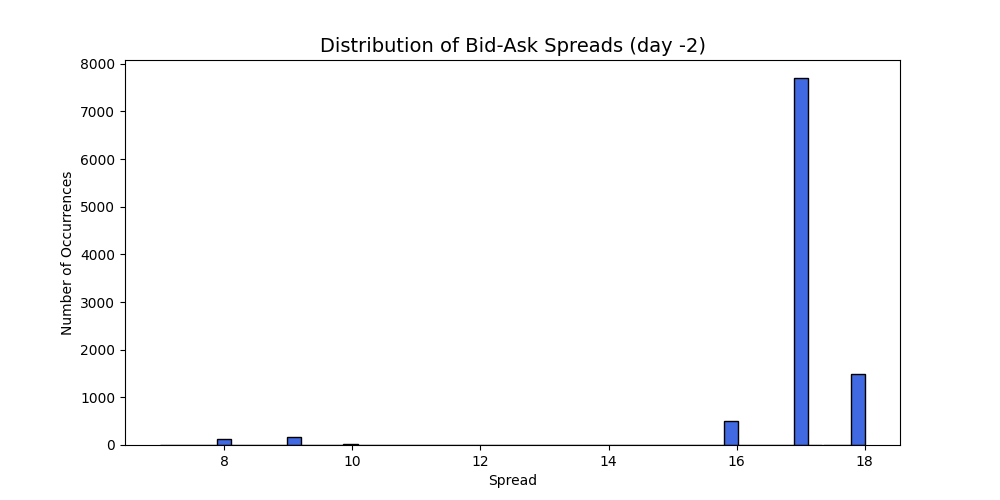

In [11]:
# data
bid_ask = product_df
bid_ask_2 = product_df_2
bid_ask_3 = product_df_3

trades = product_trades
trades2 = product_trades_2
trades3 = product_trades_3

spread = bid_ask['ask_price_1'] - bid_ask['bid_price_1']
spread2 = bid_ask_2['ask_price_1'] - bid_ask_2['bid_price_1']
spread3 = bid_ask_3['ask_price_1'] - bid_ask_3['bid_price_1']

midtrade = bid_ask.join(trades, how='inner')
midtrade2 = bid_ask_2.join(trades2, how='inner')
midtrade3 = bid_ask_3.join(trades3, how='inner')

trade_spread = midtrade['ask_price_1'] - midtrade['bid_price_1']
trade_spread_2 = midtrade2['ask_price_1'] - midtrade2['bid_price_1']
trade_spread_3 = midtrade3['ask_price_1'] - midtrade3['bid_price_1']


print("Average spread: ", spread.mean())

# Show histogram of spreads
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads (day -2)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Number of Occurrences')
plt.show()

Average spread:  16.8981


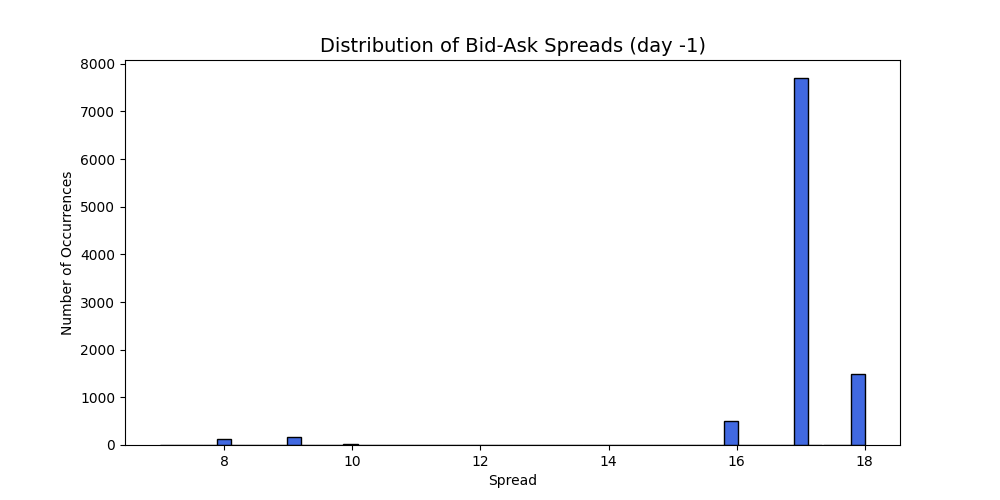

In [12]:
print("Average spread: ", spread2.mean()) 

plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads (day -1)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Number of Occurrences')
plt.show()


Average spread:  16.7908


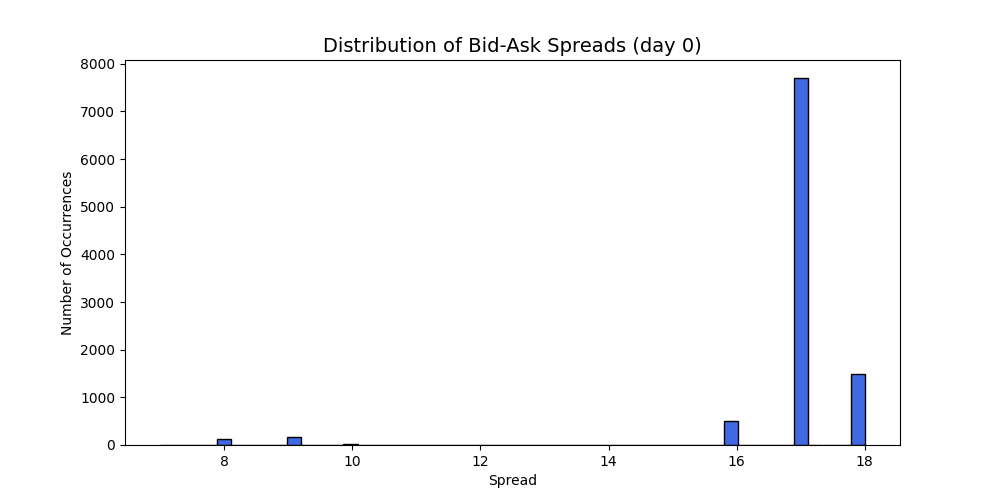

In [13]:
print("Average spread: ", spread3.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads (day 0)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Number of Occurrences')
plt.show()


Average spread for trades:  16.890829694323145


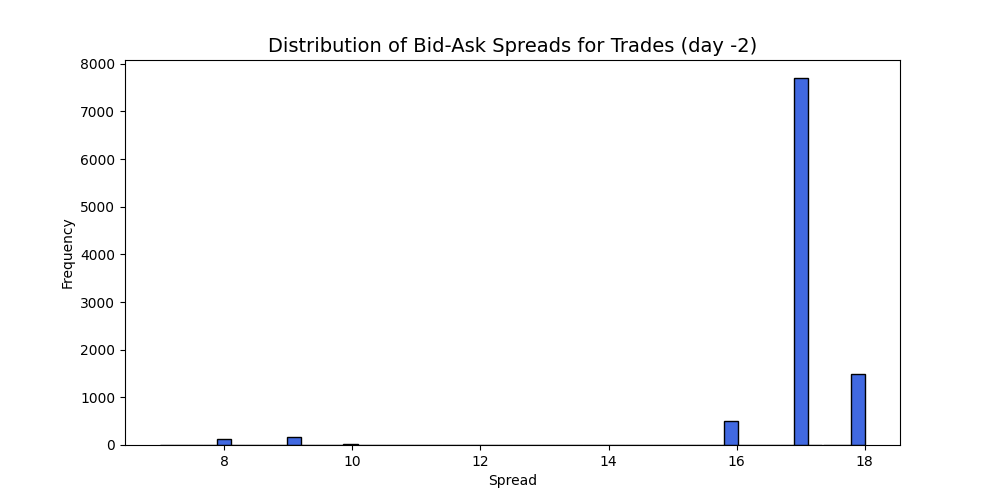

In [14]:
print("Average spread for trades: ", trade_spread.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads for Trades (day -2)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Frequency')
plt.show()

Average spread for trades:  16.819607843137256


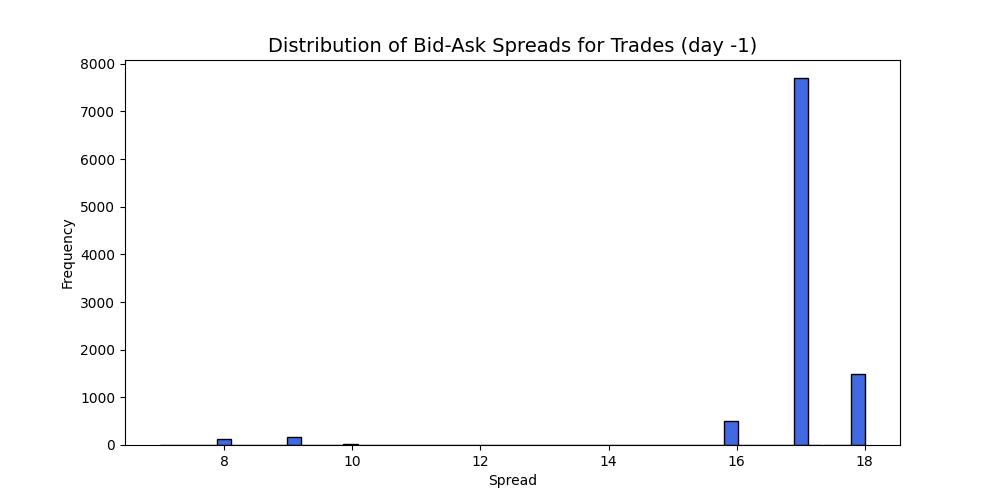

In [15]:
print("Average spread for trades: ", trade_spread_2.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads for Trades (day -1)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Frequency')
plt.show()

Average spread for trades:  16.82730923694779


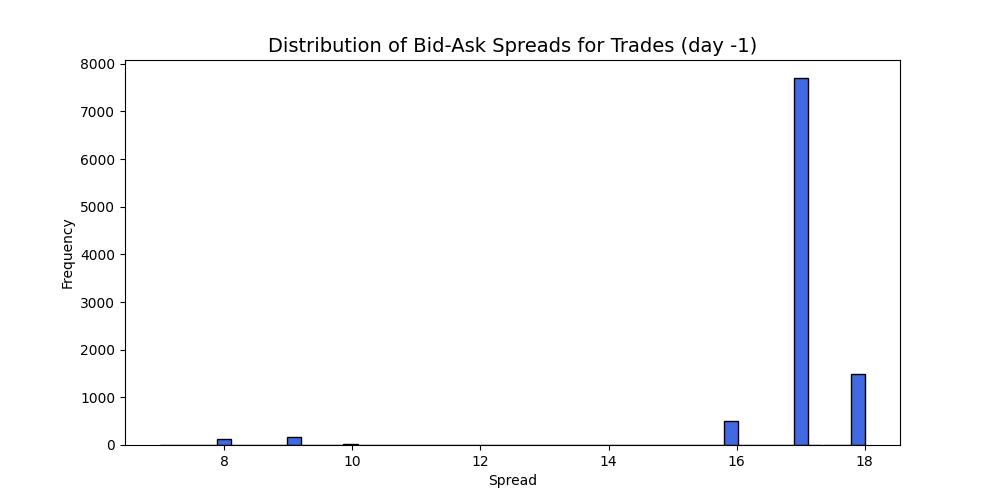

In [16]:
print("Average spread for trades: ", trade_spread_3.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads for Trades (day -1)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Frequency')
plt.show()